In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import h5py
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/")
import torch
import torch.nn as nn
import torch.utils.data as utils
import torch.optim as optim
device = torch.device('cuda:0')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
import json
from nflows.flows.base import Flow
from nflows.flows.autoregressive import MaskedAutoregressiveFlow
from nflows.distributions.normal import StandardNormal, ConditionalDiagonalNormal, FullNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform, MaskedPiecewiseQuadraticAutoregressiveTransform, MaskedPiecewiseRationalQuadraticAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def make_flow(num_features,context_features,kwargs,perm=True):
    base_dist = StandardNormal(shape=[num_features])
    transforms = []
    for i in range(kwargs['num_layers']):
        transforms.append(MaskedPiecewiseRationalQuadraticAutoregressiveTransform(features=num_features,
                                                                                  context_features=context_features,
                                                                                hidden_features=kwargs['hidden_features'],
                                                                                num_bins=kwargs['num_bins'],
                                                                                num_blocks=kwargs['num_blocks_per_layer'],
                                                                                tail_bound=kwargs['tail_bound'], 
                                                                                tails=kwargs['tails']))
    transform = CompositeTransform(transforms)
    flow = Flow(transform, base_dist)
    return flow

def train(flow,trainData,trainContext,n_context,NF_kwargs,bs=10000,n_epoch=100,patience=20,learning_rate=1e-3,print_interval=10,T_max=-1,eta_min=-1,scheduler=None,clip=None,outName="flow",outDir="flow_on_losses"):
    device = torch.device("cuda:0")
    print(f"{len(trainData)} training events")
    if clip is not None:
        trainData = trainData[np.all(np.abs(trainData)<clip,axis=1)]
    if bs < 1:
        bs = int(bs*trainData.shape[0])
    train = torch.tensor(np.concatenate((trainData,trainContext),axis=1),device=device)
    loader = utils.DataLoader(train,batch_size=bs,shuffle=True,generator=torch.Generator(device=device))

    
    with open(f"{outDir}/{outName}.json","w") as f:
        json.dump(NF_kwargs,f,indent=4)

    flow = flow.to(device)
    optimizer = optim.Adam(flow.parameters(),lr=learning_rate)
    if scheduler is not None:
        scheduler = scheduler(optimizer)
    else:
        T_max = T_max if T_max!=-1 else n_epoch//2
        eta_min = eta_min if eta_min!=-1 else 0.01*learning_rate
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=T_max,eta_min=eta_min,verbose=False)

    min_loss = 1e+8
    train_losses = []
    patience_count = 0
    saveName = f"{outDir}/{outName}.pt"
    for i in range(n_epoch):
        if patience_count == patience:
            break
        epoch_losses = []
        for batch_idx, x in enumerate(loader):
            x1 = x[:,:-n_context]
            x2 = x[:,-n_context:]
            optimizer.zero_grad()
            loss = -flow.log_prob(inputs=x1,context=x2)[0].mean()
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            if loss.item() < min_loss:
                min_loss = loss.item()
                torch.save(flow.state_dict(),saveName)
        epoch_loss = np.min(epoch_losses)
        train_losses.append(epoch_loss)
        if (i + 1) % print_interval == 0:
            print('Iteration {} Complete'.format(i + 1))
            print('Loss: ', epoch_loss)
        if epoch_loss == min_loss:
            patience_count = 0
        else:
            patience_count += 1
        scheduler.step()

    plt.figure(figsize=(8,6))
    plt.plot(np.arange(len(train_losses)),train_losses)
    plt.xlabel('Epoch',fontsize=16)
    plt.ylabel('Loss',fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(f"{outDir}/{outName}-train.pdf")

    del loader, trainData, optimizer, scheduler
    torch.cuda.empty_cache()
    flow.load_state_dict(torch.load(f'{outDir}/{outName}.pt'))
    return flow

In [4]:
def plotLosses_mjjBins(f1,lossNames):
    losses_bkg = []
    with h5py.File(f1,"r") as f:
        keys = list(f.keys())
        print(keys)
        mjj_bkg = f['mjj'][()]
        for l in lossNames:
            losses_bkg.append(f[l][()].reshape(-1,1))
    losses_bkg = np.concatenate(losses_bkg,axis=1)
    mean_loss_bkg = losses_bkg.mean(axis=0)
    std_loss_bkg = losses_bkg.std(axis=0)
    mean_mjj_bkg = mjj_bkg.mean()
    std_mjj_bkg = mjj_bkg.std()
    losses_bkg = (losses_bkg-mean_loss_bkg)/std_loss_bkg

    nrow = len(lossNames)//2 + len(lossNames)%2
    plt.figure(figsize=(12,5*nrow))
    mbins = np.arange(2000,5500,step=500)
    mjj_binned = np.digitize(mjj_bkg,mbins)
    bins = np.linspace(-5,20,num=100)
    for i,l in enumerate(lossNames):
        plt.subplot(nrow,2,i+1)
        for j in range(1,len(mbins)):
            cut = mjj_binned==j
            h = plt.hist(losses_bkg[:,i][cut],histtype='step',density=True,label=f"{mbins[j-1]} < mjj < {mbins[j]}",bins=bins)
        plt.legend(loc='upper right')
        plt.yscale('log')
        plt.xlabel(lossNames[i])
    print(np.corrcoef(np.concatenate((mjj_bkg.reshape(-1,1),losses_bkg),axis=1),rowvar=False))

In [5]:
import matplotlib.colors as colors
def quakSpace_mjjcolor(f1,loss_sig,loss_bkg,xmin=0,xmax=50,ymin=0,ymax=50):
    losses_bkg = []
    with h5py.File(f1,"r") as f:
        keys = list(f.keys())
        print(keys)
        mjj_bkg = f['mjj'][()]
        lb = f[loss_bkg][()]
        ls = f[loss_sig][()]
    cut = mjj_bkg>2000
    mjj_bkg = mjj_bkg[cut]
    lb = lb[cut]
    ls = ls[cut]
    x_bins = np.linspace(xmin,xmax,50)
    y_bins = np.linspace(ymin,ymax,50)
    bin_means, _, _ = np.histogram2d(lb, ls, bins=[x_bins, y_bins], weights=mjj_bkg)
    bin_counts, _, _ = np.histogram2d(lb, ls, bins=[x_bins, y_bins])
    bin_means /= bin_counts
    print(np.max(bin_means))
    
    # Create the plot
    plt.figure(figsize=(8,8))
    plt.imshow(bin_means.T, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='jet')
    plt.colorbar()
    plt.xlabel(loss_bkg)
    plt.ylabel(loss_sig)
    plt.title(f1.split("/")[-1])

['BKG', 'BKG_mjjCond', 'BKG_mjjFlat', 'DATA', 'DATA_mjjCond', 'DATA_mjjFlat', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp5000_B400_T170', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_heavy', 'top55_heavy_mjjCond', 'top66_heavy', 'top66_heavy_mjjCond', 'truth_label']


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


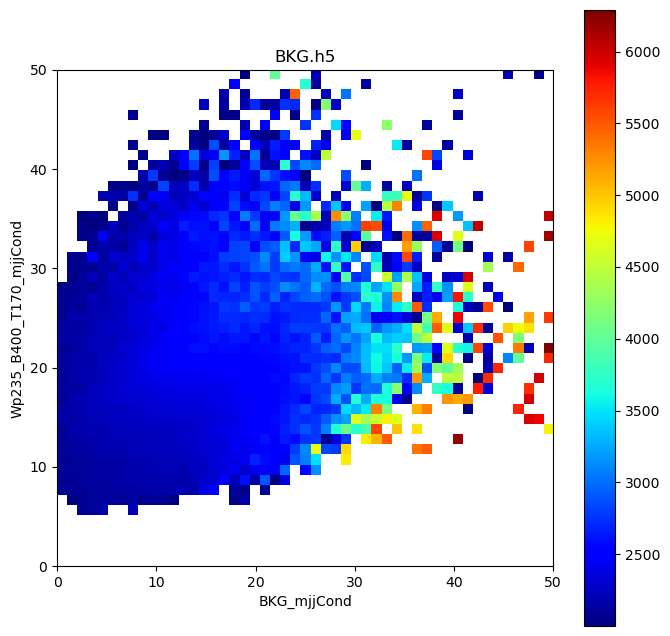

In [64]:
quakSpace_mjjcolor("lossEvals/BKG.h5","Wp235_B400_T170_mjjCond","BKG_mjjCond")

['BKG', 'BKG_mjjCond', 'BKG_mjjFlat', 'DATA', 'DATA_mjjCond', 'DATA_mjjFlat', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp5000_B400_T170', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_heavy', 'top55_heavy_mjjCond', 'top66_heavy', 'top66_heavy_mjjCond']


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


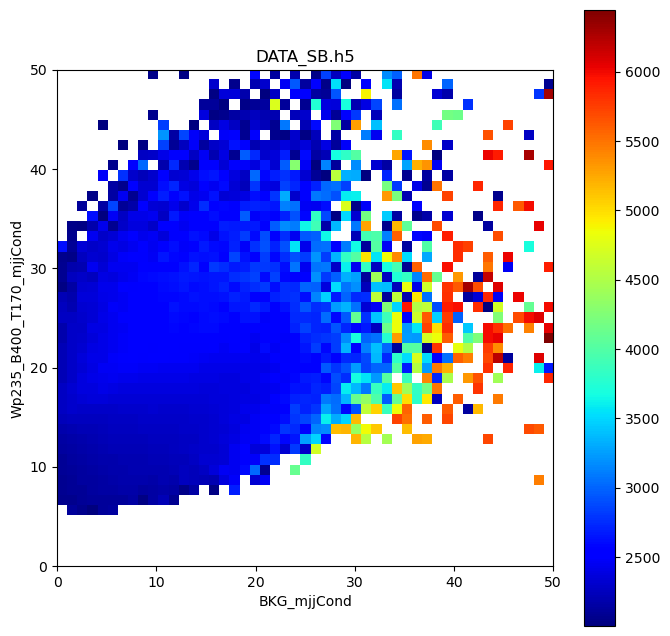

In [45]:
quakSpace_mjjcolor("lossEvals/DATA_SB.h5","Wp235_B400_T170_mjjCond","BKG_mjjCond")

['BKG', 'BKG_mjjCond', 'BKG_mjjFlat', 'DATA', 'DATA_mjjCond', 'DATA_mjjFlat', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp5000_B400_T170', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_heavy', 'top55_heavy_mjjCond', 'top66_heavy', 'top66_heavy_mjjCond', 'truth_label']


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


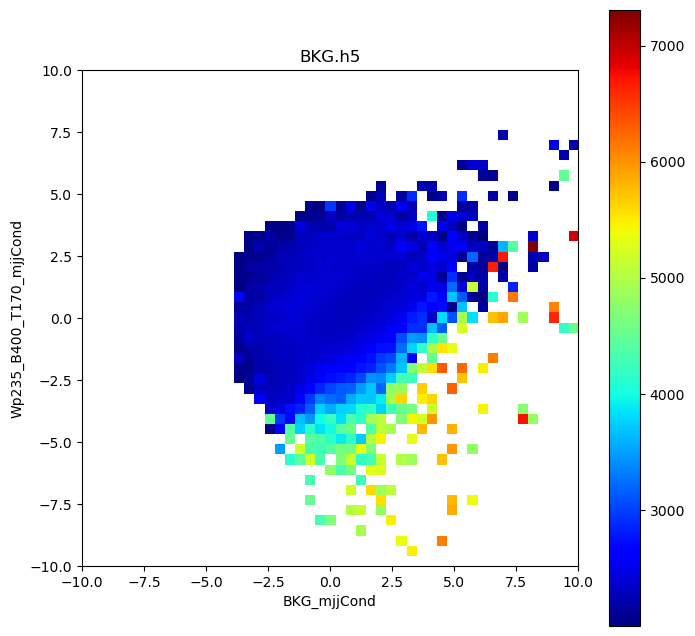

In [53]:
quakSpace_mjjcolor("lossEvals_pcaDecorr_boxCox/BKG.h5","Wp235_B400_T170_mjjCond","BKG_mjjCond",xmin=-10,xmax=10,ymin=-10,ymax=10)

['BKG', 'BKG_mjjCond', 'BKG_mjjFlat', 'DATA', 'DATA_mjjCond', 'DATA_mjjFlat', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp5000_B400_T170', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_heavy', 'top55_heavy_mjjCond', 'top66_heavy', 'top66_heavy_mjjCond']


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


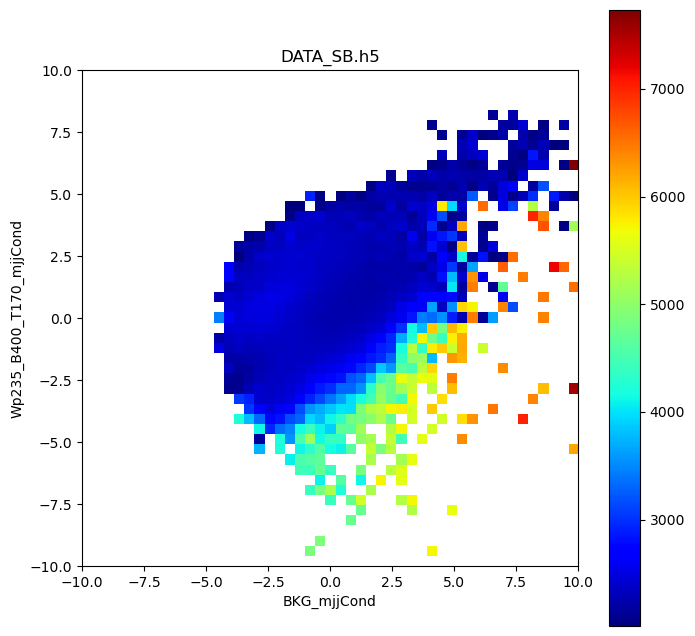

In [56]:
quakSpace_mjjcolor("lossEvals_pcaDecorr_boxCox/DATA_SB.h5","Wp235_B400_T170_mjjCond","BKG_mjjCond",xmin=-10,xmax=10,ymin=-10,ymax=10)

['BKG', 'BKG_flowDecorr', 'BKG_mjjCond', 'BKG_mjjFlat', 'BKG_mjjFlat_flowDecorr', 'DATA', 'DATA_flowDecorr', 'DATA_mjjCond', 'DATA_mjjFlat', 'DATA_mjjFlat_flowDecorr', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp2000_B400_T170_flowDecorr', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp3000_B400_T170_flowDecorr', 'Wp5000_B400_T170', 'Wp5000_B400_T170_flowDecorr', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_he

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


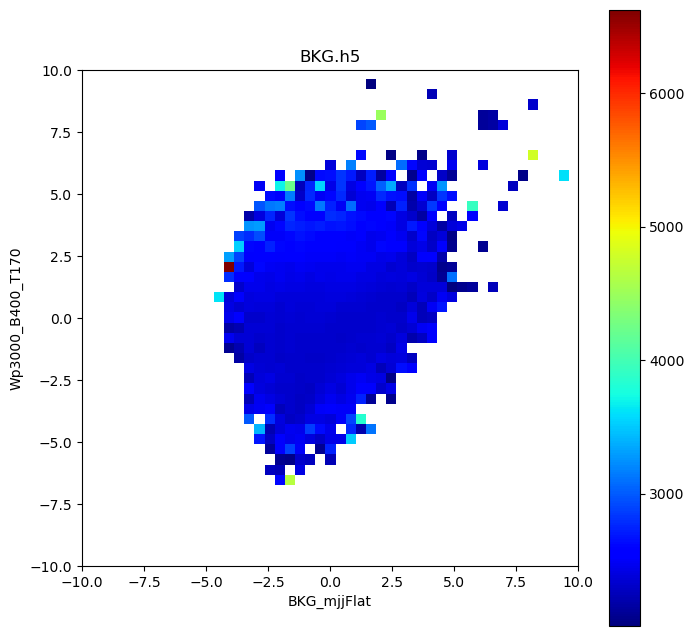

In [14]:
quakSpace_mjjcolor("lossEvals_pcaDecorr_boxCox/BKG.h5","Wp3000_B400_T170","BKG_mjjFlat",xmin=-10,xmax=10,ymin=-10,ymax=10)

['BKG', 'BKG_flowDecorr', 'BKG_mjjCond', 'BKG_mjjFlat', 'BKG_mjjFlat_flowDecorr', 'DATA', 'DATA_flowDecorr', 'DATA_mjjCond', 'DATA_mjjFlat', 'DATA_mjjFlat_flowDecorr', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp2000_B400_T170_flowDecorr', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp3000_B400_T170_flowDecorr', 'Wp5000_B400_T170', 'Wp5000_B400_T170_flowDecorr', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_he

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


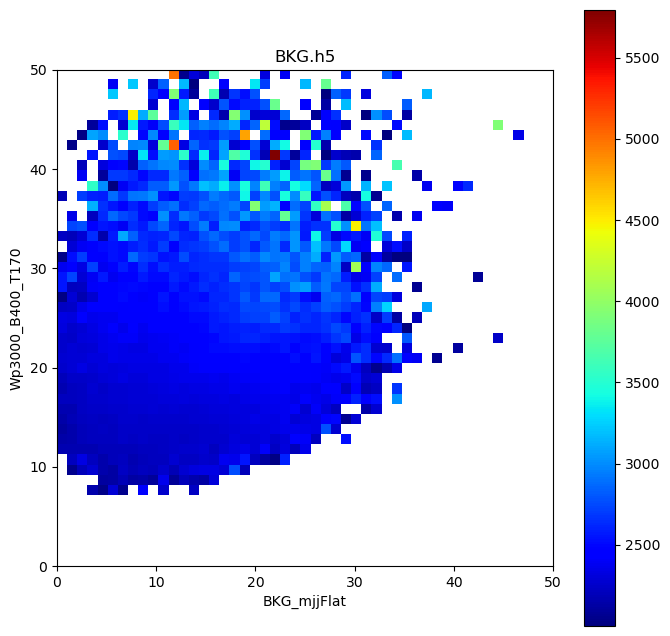

In [15]:
quakSpace_mjjcolor("lossEvals/BKG.h5","Wp3000_B400_T170","BKG_mjjFlat")

['BKG', 'BKG_flowDecorr', 'BKG_mjjCond', 'BKG_mjjFlat', 'BKG_mjjFlat_flowDecorr', 'DATA', 'DATA_flowDecorr', 'DATA_mjjCond', 'DATA_mjjFlat', 'DATA_mjjFlat_flowDecorr', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp2000_B400_T170_flowDecorr', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp3000_B400_T170_flowDecorr', 'Wp5000_B400_T170', 'Wp5000_B400_T170_flowDecorr', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_he

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


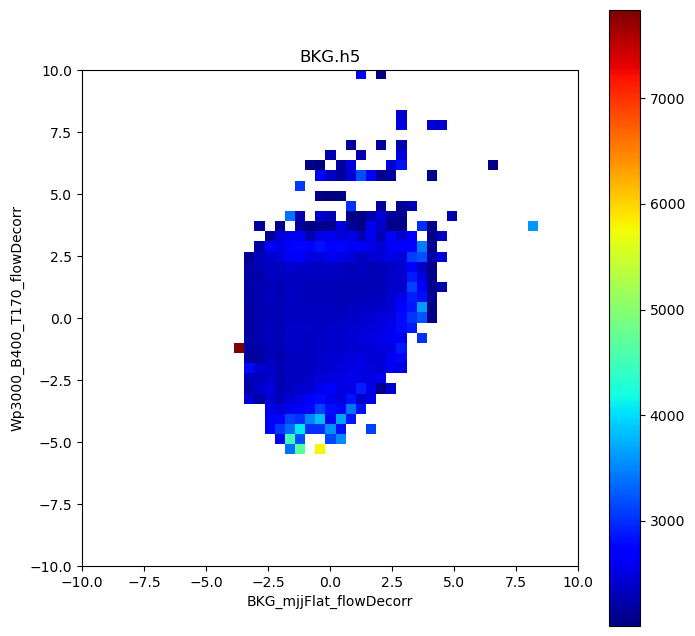

In [16]:
quakSpace_mjjcolor("lossEvals_pcaDecorr_boxCox/BKG.h5","Wp3000_B400_T170_flowDecorr","BKG_mjjFlat_flowDecorr",xmin=-10,xmax=10,ymin=-10,ymax=10)

['BKG', 'BKG_flowDecorr', 'BKG_mjjCond', 'BKG_mjjFlat', 'BKG_mjjFlat_flowDecorr', 'DATA', 'DATA_flowDecorr', 'DATA_mjjCond', 'DATA_mjjFlat', 'DATA_mjjFlat_flowDecorr', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp2000_B400_T170_flowDecorr', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp3000_B400_T170_flowDecorr', 'Wp5000_B400_T170', 'Wp5000_B400_T170_flowDecorr', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_he

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


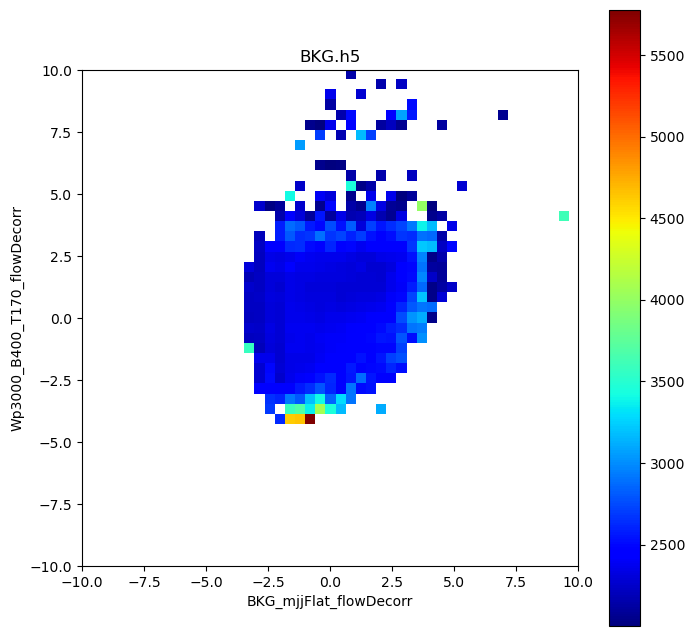

In [18]:
quakSpace_mjjcolor("lossEvals/BKG.h5","Wp3000_B400_T170_flowDecorr","BKG_mjjFlat_flowDecorr",xmin=-10,xmax=10,ymin=-10,ymax=10)

['BKG', 'BKG_mjjCond', 'BKG_mjjFlat', 'DATA', 'DATA_mjjCond', 'DATA_mjjFlat', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp5000_B400_T170', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_heavy', 'top55_heavy_mjjCond', 'top66_heavy', 'top66_heavy_mjjCond']


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


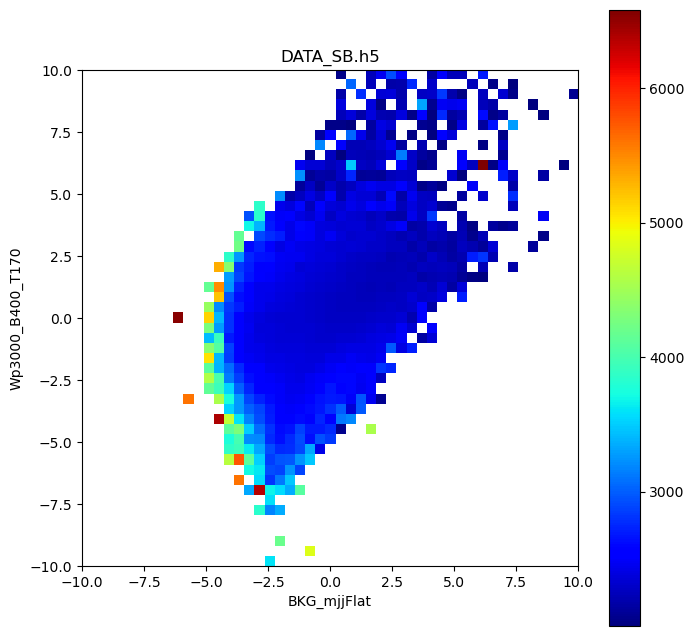

In [61]:
quakSpace_mjjcolor("lossEvals_pcaDecorr_boxCox/DATA_SB.h5","Wp3000_B400_T170","BKG_mjjFlat",xmin=-10,xmax=10,ymin=-10,ymax=10)

['BKG', 'BKG_mjjCond', 'BKG_mjjFlat', 'DATA', 'DATA_mjjCond', 'DATA_mjjFlat', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp5000_B400_T170', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_heavy', 'top55_heavy_mjjCond', 'top66_heavy', 'top66_heavy_mjjCond']


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


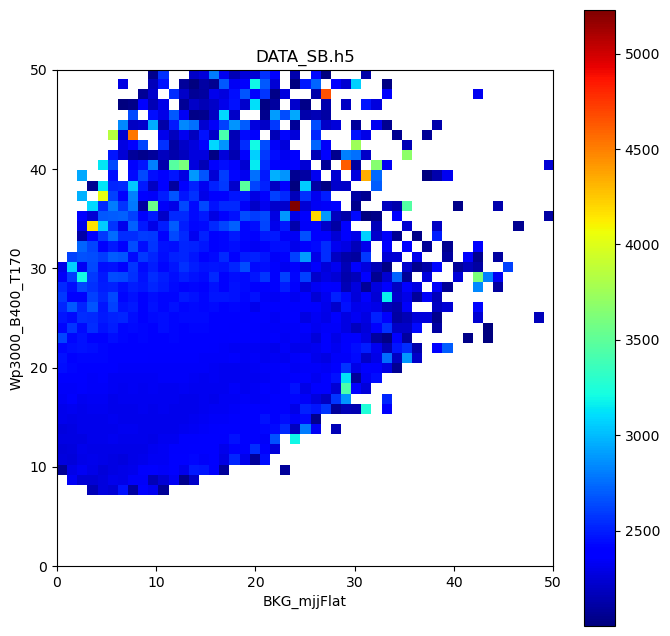

In [62]:
quakSpace_mjjcolor("lossEvals/DATA_SB.h5","Wp3000_B400_T170","BKG_mjjFlat")

['BKG', 'BKG_flowDecorr', 'BKG_mjjCond', 'BKG_mjjFlat', 'BKG_mjjFlat_flowDecorr', 'DATA', 'DATA_flowDecorr', 'DATA_mjjCond', 'DATA_mjjFlat', 'DATA_mjjFlat_flowDecorr', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp2000_B400_T170_flowDecorr', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp3000_B400_T170_flowDecorr', 'Wp5000_B400_T170', 'Wp5000_B400_T170_flowDecorr', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_he

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


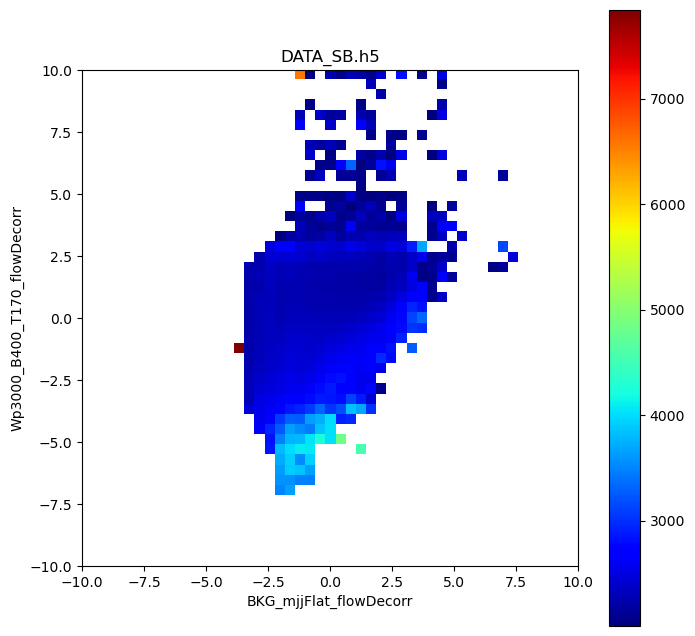

In [19]:
quakSpace_mjjcolor("lossEvals_pcaDecorr_boxCox/DATA_SB.h5","Wp3000_B400_T170_flowDecorr","BKG_mjjFlat_flowDecorr",xmin=-10,xmax=10,ymin=-10,ymax=10)

['BKG', 'BKG_flowDecorr', 'BKG_mjjCond', 'BKG_mjjFlat', 'BKG_mjjFlat_flowDecorr', 'DATA', 'DATA_flowDecorr', 'DATA_mjjCond', 'DATA_mjjFlat', 'DATA_mjjFlat_flowDecorr', 'M170-170', 'M170-170-flow0', 'M170-170-flow1', 'M170-400', 'M170-400-flow0', 'M170-400-flow1', 'M25-170', 'M25-170-flow0', 'M25-25', 'M25-25-flow0', 'M25-400', 'M25-400-flow0', 'M25-80', 'M25-80-flow0', 'M400-400', 'M400-400-flow0', 'M400-400-flow1', 'M80-170', 'M80-170-flow0', 'M80-170-flow1', 'M80-400', 'M80-400-flow0', 'M80-400-flow1', 'M80-80', 'M80-80-flow0', 'M80-80-flow1', 'Qstar2000_W400', 'RSG3000', 'Wkk3000_R400', 'Wp2000_B400_T170', 'Wp2000_B400_T170_flowDecorr', 'Wp235_B170_T170_mjjCond', 'Wp235_B400_T170_mjjCond', 'Wp3000_B400_T170', 'Wp3000_B400_T170_flowDecorr', 'Wp5000_B400_T170', 'Wp5000_B400_T170_flowDecorr', 'XYY3000_Y170_Yp170', 'flow0', 'flow1', 'jet1_mass', 'jet2_mass', 'mjj', 'top22_heavy', 'top22_heavy_mjjCond', 'top33_heavy', 'top33_heavy_mjjCond', 'top43_heavy', 'top43_heavy_mjjCond', 'top55_he

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in true_divide


nan


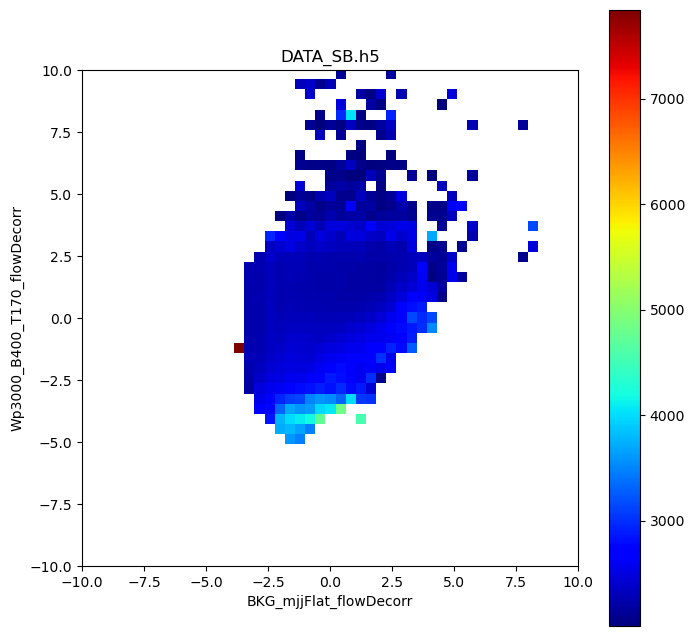

In [20]:
quakSpace_mjjcolor("lossEvals/DATA_SB.h5","Wp3000_B400_T170_flowDecorr","BKG_mjjFlat_flowDecorr",xmin=-10,xmax=10,ymin=-10,ymax=10)

# Training flows to decorrelate losses from mjj

In [6]:
from tqdm import tqdm
import os
def decorrelationFlow(loss,NF_kwargs,nTrain=100000,nTest=100000,evalBatch=100000):
    with h5py.File("lossEvals/BKG.h5","r") as f:
        bkg_loss = f[loss][()]
        loss_mean = bkg_loss.mean()
        loss_std = bkg_loss.std()
        bkg_loss = (bkg_loss-loss_mean)/loss_std
        bkg_mjj = f['mjj'][()]
        mjj_mean = bkg_mjj.mean()
        mjj_std = bkg_mjj.std()
        bkg_mjj = (bkg_mjj-mjj_mean)/mjj_std
    flow = make_flow(1,1,NF_kwargs)
    inds = np.random.choice(bkg_mjj.shape[0],size=nTrain+nTest,replace=False)
    train_data = bkg_loss[inds[:nTrain]]
    train_mass = bkg_mjj[inds[:nTrain]]
    test_data = bkg_loss[inds[nTrain:nTrain+nTest]]
    test_mass = bkg_mjj[inds[nTrain:nTrain+nTest]]
    flow = train(flow,train_data.reshape(-1,1),train_mass.reshape(-1,1),1,NF_kwargs,bs=10000,n_epoch=100,patience=20,learning_rate=1e-3,
             print_interval=10,T_max=-1,eta_min=-1,scheduler=None,clip=None,outName=f"flow_{loss}",outDir="lossDecorrelatingFlows")
    
    flow.eval()
    samples = flow.sample(1,context=torch.tensor(test_mass)).detach().cpu().numpy().reshape(test_mass.shape[0],1)
    plt.figure(figsize=(5,5))
    h,bins,_ = plt.hist(test_data,histtype='step',density=True,bins=100)
    h,bins,_ = plt.hist(samples[:,0],histtype='step',density=True,bins=bins)
    plt.yscale('log')
    plt.title('flow density estimation')
    plt.xlabel(loss)
    plt.savefig(f'lossDecorrelatingFlows/density_est_{loss}.pdf')
    
    all_files = [f for f in os.listdir("lossEvals/") if ".h5" in f]
    JME_systs = ["JES_up","JES_down","JER_up","JER_down","JMS_up","JMS_down","JMR_up","JMR_down"]
    possible = [loss] + [f"{loss}_{s}" for s in JME_systs]
    for file in tqdm(all_files):
        with h5py.File(f"lossEvals/{file}","r") as fin:
            relevant = [k for k in fin.keys() if k in possible]
        for rel_loss in relevant:
            curr_sys = ""
            for jsys in JME_systs:
                if jsys in rel_loss:
                    curr_sys = f"_{jsys}"
            outBranch = f"{loss}_flowDecorr"+curr_sys
            with h5py.File(f"lossEvals/{file}","r+") as fin:
                in_loss = fin[rel_loss][()]
                in_loss = (in_loss-loss_mean)/loss_std
                in_mjj = fin['mjj'][()]
                in_mjj = (in_mjj-mjj_mean)/mjj_std
                if outBranch in fin.keys():
                    del fin[outBranch]
            nev = in_loss.shape[0]
            n_chunk = nev//evalBatch + int(nev%evalBatch > 0)
            splits = np.array_split(np.arange(nev),n_chunk)
            transformed = []
            for split in splits:
                inputs = in_loss[split].reshape(-1,1)
                context = in_mjj[split].reshape(-1,1)
                with torch.no_grad():
                    transformed.append(flow.transform_to_noise(inputs=torch.tensor(inputs),context=torch.tensor(context)).detach().cpu().numpy()[:,0])
                del inputs,context
            transformed = np.concatenate(transformed,axis=0)
            with h5py.File(f"lossEvals/{file}","r+") as fin:
                fin.create_dataset(outBranch,data=transformed)
            del in_loss, in_mjj
            torch.cuda.empty_cache()

100000 training events
Iteration 10 Complete
Loss:  1.4090220928192139
Iteration 20 Complete
Loss:  1.399658203125
Iteration 30 Complete
Loss:  1.3949223756790161
Iteration 40 Complete
Loss:  1.4014077186584473
Iteration 50 Complete
Loss:  1.3939143419265747
Iteration 60 Complete
Loss:  1.3950037956237793
Iteration 70 Complete
Loss:  1.3955439329147339


100%|██████████| 90/90 [02:34<00:00,  1.71s/it]


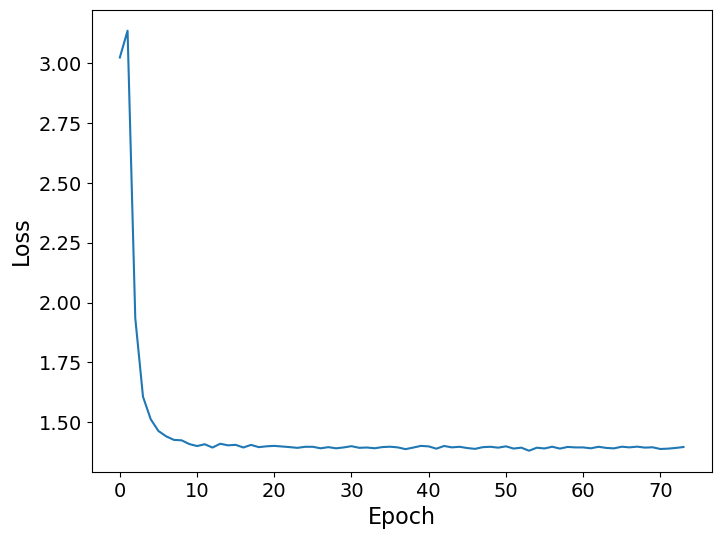

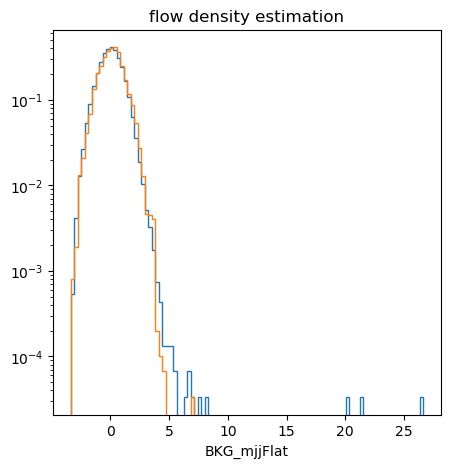

In [7]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":15,"hidden_features":100,
             "num_layers":3,"num_bins":40,"num_blocks_per_layer":3,"tails":"linear"}
decorrelationFlow("BKG_mjjFlat",NF_kwargs)

100000 training events
Iteration 10 Complete
Loss:  1.2953060865402222
Iteration 20 Complete
Loss:  1.291221261024475
Iteration 30 Complete
Loss:  1.2907718420028687


100%|██████████| 90/90 [02:24<00:00,  1.61s/it]


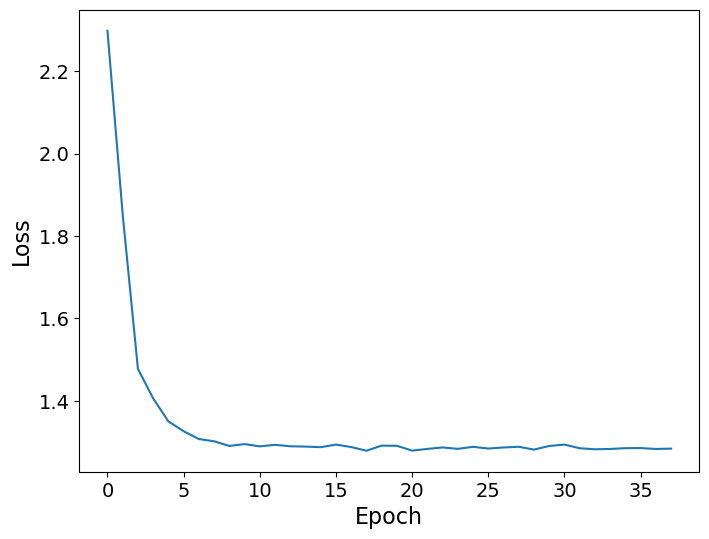

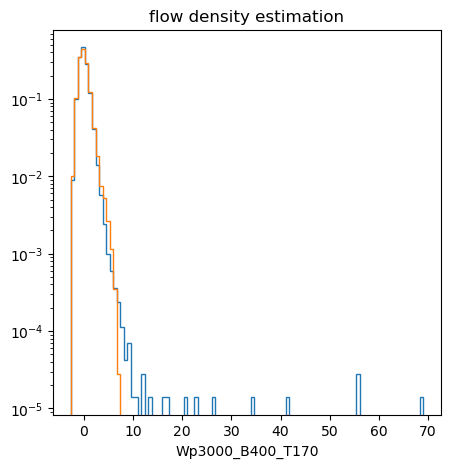

In [8]:
decorrelationFlow("Wp3000_B400_T170",NF_kwargs)

100000 training events
Iteration 10 Complete
Loss:  1.3682305812835693
Iteration 20 Complete
Loss:  1.3545771837234497
Iteration 30 Complete
Loss:  1.3543490171432495
Iteration 40 Complete
Loss:  1.3574446439743042
Iteration 50 Complete
Loss:  1.351886510848999
Iteration 60 Complete
Loss:  1.351503849029541


100%|██████████| 90/90 [02:18<00:00,  1.54s/it]


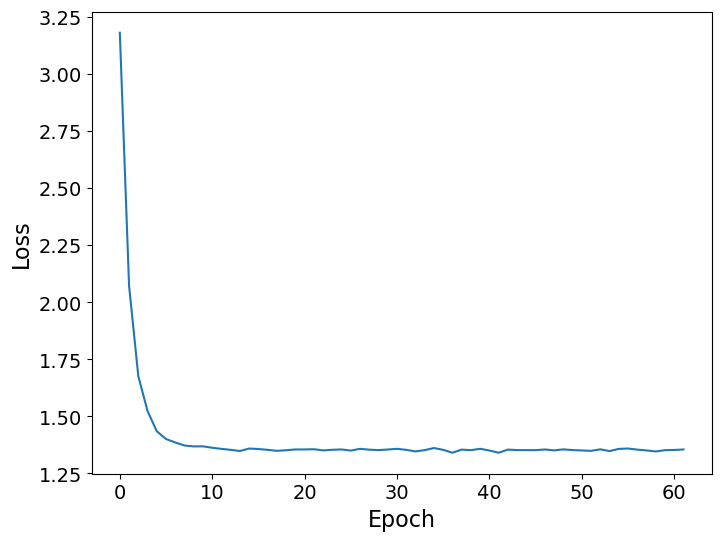

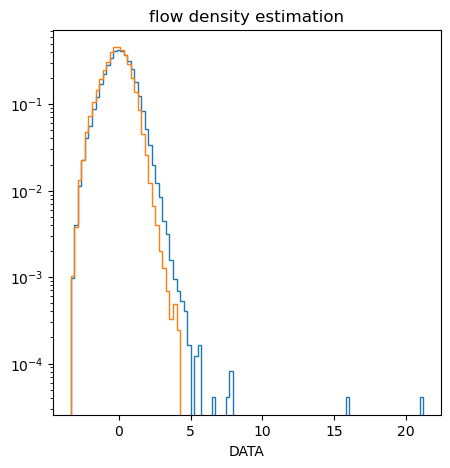

In [9]:
decorrelationFlow("DATA",NF_kwargs)

100000 training events
Iteration 10 Complete
Loss:  1.3894654512405396
Iteration 20 Complete
Loss:  1.3905397653579712
Iteration 30 Complete
Loss:  1.388106107711792


100%|██████████| 90/90 [02:16<00:00,  1.52s/it]


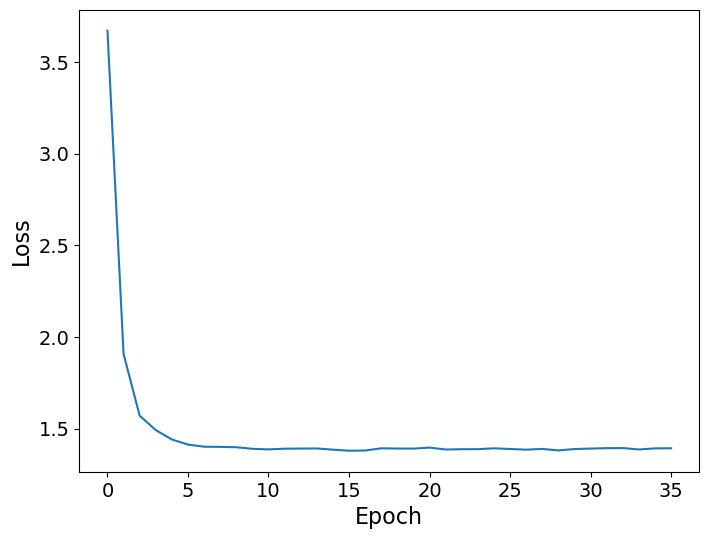

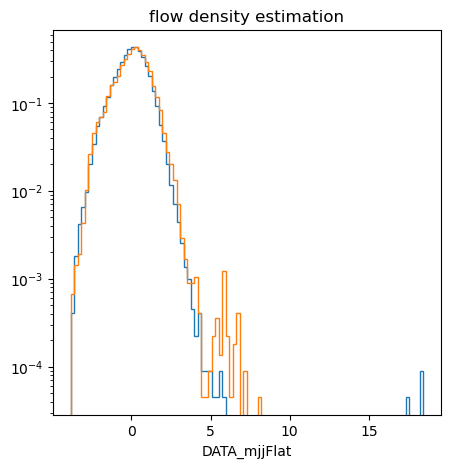

In [10]:
decorrelationFlow("DATA_mjjFlat",NF_kwargs)

100000 training events
Iteration 10 Complete
Loss:  1.4016170501708984
Iteration 20 Complete
Loss:  1.3753138780593872
Iteration 30 Complete
Loss:  1.3714691400527954
Iteration 40 Complete
Loss:  1.3705534934997559
Iteration 50 Complete
Loss:  1.3791637420654297


100%|██████████| 90/90 [02:19<00:00,  1.56s/it]


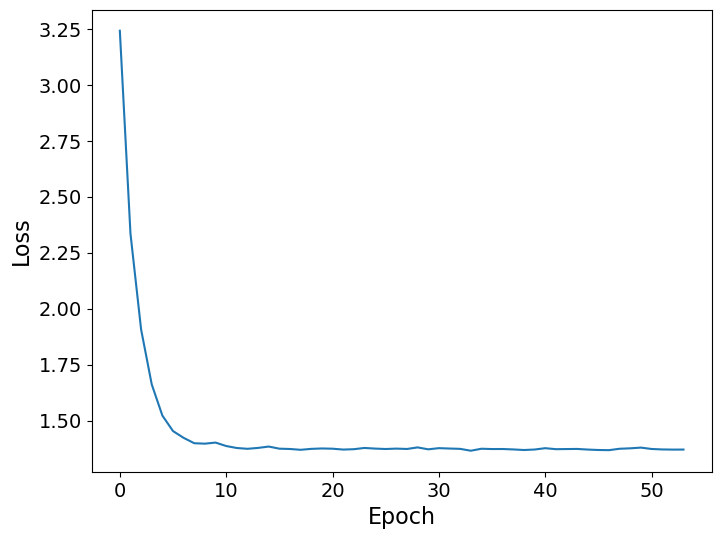

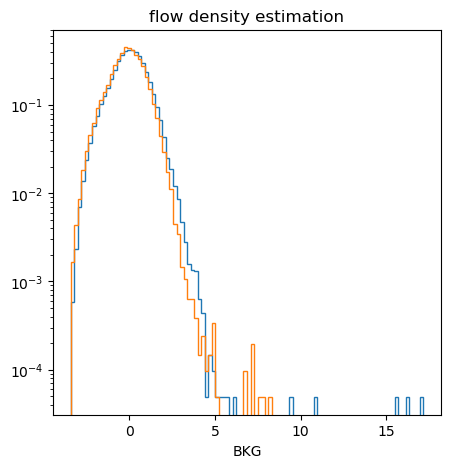

In [11]:
decorrelationFlow("BKG",NF_kwargs)

100000 training events
Iteration 10 Complete
Loss:  1.2630077600479126
Iteration 20 Complete
Loss:  1.2516025304794312
Iteration 30 Complete
Loss:  1.2470852136611938
Iteration 40 Complete
Loss:  1.251248836517334
Iteration 50 Complete
Loss:  1.2456862926483154


100%|██████████| 90/90 [02:28<00:00,  1.65s/it]


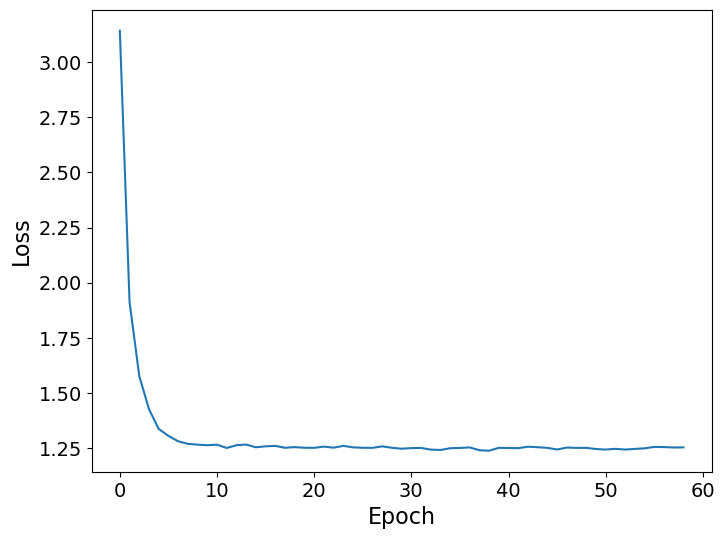

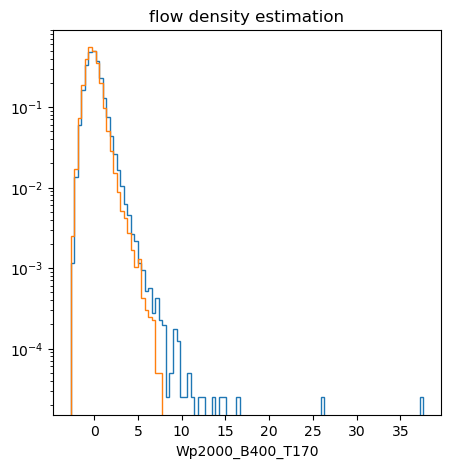

In [12]:
decorrelationFlow("Wp2000_B400_T170",NF_kwargs)

100000 training events
Iteration 10 Complete
Loss:  1.278728723526001
Iteration 20 Complete
Loss:  1.2575103044509888
Iteration 30 Complete
Loss:  1.247478723526001
Iteration 40 Complete
Loss:  1.2519161701202393
Iteration 50 Complete
Loss:  1.2532678842544556
Iteration 60 Complete
Loss:  1.2534085512161255


100%|██████████| 90/90 [02:32<00:00,  1.70s/it]


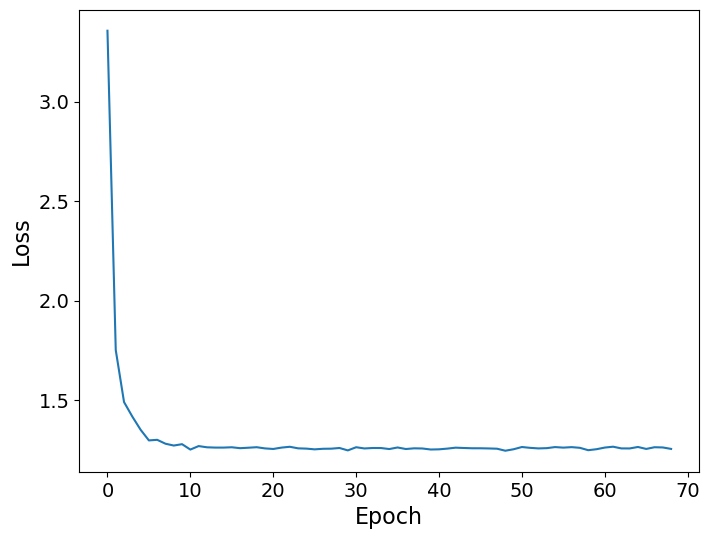

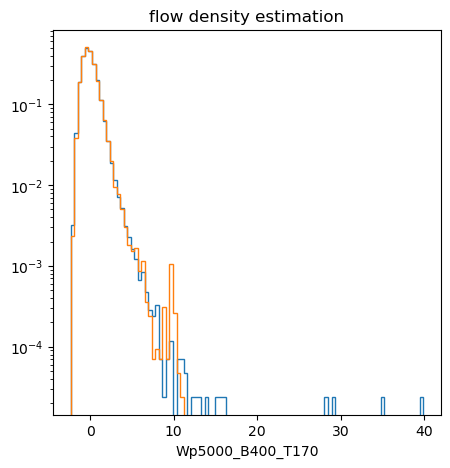

In [13]:
decorrelationFlow("Wp5000_B400_T170",NF_kwargs)